# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [ ] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [ ] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset

In [4]:
target_name = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_name)

In [6]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.215355,0.215355,0.215355,sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,10,20,30,0.333333,0.666667,0.034369,0.034369,0.034369,sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.479921,0.479921,0.479921,C36
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,5,24,29,0.172414,0.827586,0.457352,0.457352,0.457352,chi
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,15,38,53,0.283019,0.716981,0.134967,0.112588,0.155125,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,3,10,13,0.230769,0.769231,0.326354,0.308107,0.342791,mu
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.224750,0.203664,0.243743,sigma
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,1,3,4,0.250000,0.750000,0.278101,0.278101,0.278101,fcc
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.228782,0.228782,0.228782,sigma


# Targets

Text(0.5, 0, '$V_0$')

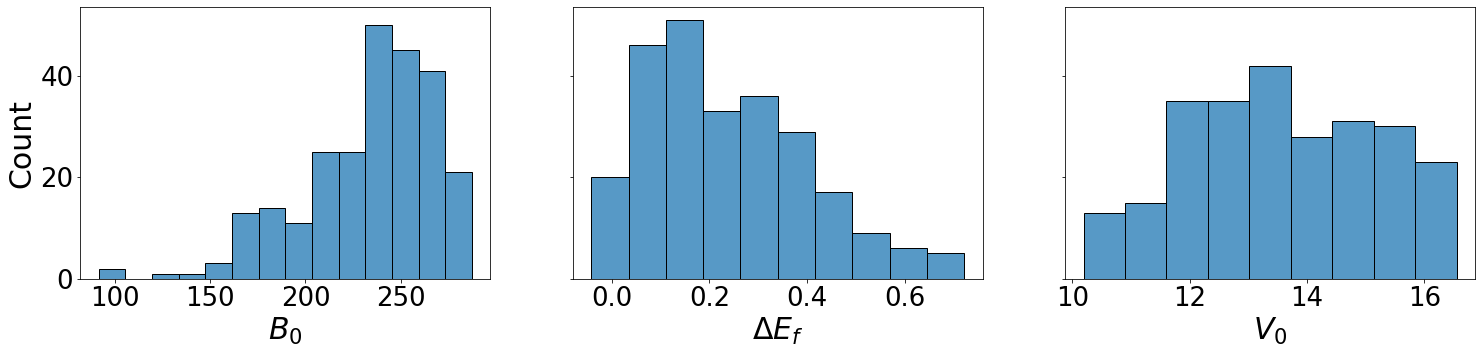

In [7]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_name], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel(r'$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel(r'$V_0$')

# Machine Learning 

In [8]:
from Tools.DatasetTools.MLConveniences import *

In [9]:
resultslocation = DS.resultslocation

## Feature sets

In [10]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [11]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,random
Fe_pv8.A15.FM,0,1,-24.768177,-5.818838,-0.766079,0.000000,-5.052759,0.0,0.000000,1.563775,...,1.061958,0.0,0.000000,1.195485,1.256253,0.000000,1.177464,0.0,0.000000,0.000743
Fe_pv12.C14.FM,1,1,-30.393489,-6.385967,-2.746742,0.000000,0.000000,0.0,-3.639226,1.735289,...,0.000000,0.0,0.563851,1.106264,1.192872,0.000000,0.000000,0.0,0.904117,0.697024
Fe_pv24Mo_sv5.chi-BBAA.FM,6,1,-48.743360,-6.846426,-1.822605,-1.296988,0.000000,0.0,-3.726834,1.462959,...,0.000000,0.0,0.208855,1.251704,1.437264,1.179086,0.000000,0.0,1.006209,0.998977
Fe_pv25Mo_sv4.chi-ABAA.FM,6,1,-55.370290,-6.786187,-1.810551,-1.271219,0.000000,0.0,-3.704418,1.481429,...,0.000000,0.0,0.210169,1.251702,1.437269,1.179082,0.000000,0.0,1.006200,0.507786
Fe_pv24.C36.FM,3,1,-61.028417,-6.696704,-6.199370,0.000000,0.000000,0.0,-0.497334,1.750070,...,0.000000,0.0,0.581228,1.081733,1.156286,0.000000,0.000000,0.0,0.901324,0.239834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,6,0,-55.370290,-6.786187,-1.810551,-1.271219,0.000000,0.0,-3.704418,1.481429,...,0.000000,0.0,0.210169,1.251702,1.437269,1.179082,0.000000,0.0,1.006200,0.694278
Fe_pv16Mo_sv8.C36-BBAAA.NM,3,0,0.653078,-7.534095,-3.218117,0.000000,0.000000,0.0,-4.315978,1.550432,...,0.000000,0.0,0.547073,1.081733,1.156284,0.000000,0.000000,0.0,0.901328,0.750994
Fe_pv8Mo_sv4.C14-BAA.NM,1,0,-0.173778,-7.354415,-3.092435,0.000000,0.000000,0.0,-4.261981,1.537340,...,0.000000,0.0,0.530717,1.106266,1.192873,0.000000,0.000000,0.0,0.904120,0.022730
Fe_pv4.fcc-cubic.NM,7,0,-12.039661,-5.267352,-5.267352,0.000000,0.000000,0.0,0.000000,1.388730,...,0.000000,0.0,0.000000,1.140021,1.140021,0.000000,0.000000,0.0,0.000000,0.070688


In [12]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_canonicalFe', 'SOAP_canonicalW', 'SOAP_specific', 'Pyscal', 'ACE', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', '0.6 Projections OS BOP', '0.7 Projections OS BOP', '0.8 Projections OS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + 0.6 Projections OS BOP', 'dataset + 0.7 Projections OS BOP', 'dataset + 0.8 Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe no CNAV', 'SOAP_canonicalW no CNAV', 'SOAP_specific no CNAV', 'Pyscal no CNAV', 'ACE no CNAV', 'Canonical BOP no CNAV', 'Projections BOP no CNAV', 'Projections OS BOP no CNAV', '0.6 Projections OS BOP no CNAV', '0.7 Projections OS BOP no CNAV', '0.8 Projections OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + Projections BOP no CNAV', 'dataset + Projections OS BOP no CNAV', 'dataset + 0.6 Projections OS BOP no CNAV', 'dataset + 0.7 Projections OS BOP no CNAV', 'dataset + 0.8 Projections OS

## test - train splits

In [13]:
samplesplit = DS.get_samplesplit()

# Optimized Models

In [14]:
models = ['Kernel Ridge', 'Random Forest','MLP']

In [15]:
scoresfiles = {model:f'{DS.dataset}/results/{DS.dataset}_{model}_OptimalScores_{target_name}.pkl'
              for model in models}

In [16]:
scoresfiles

{'Kernel Ridge': 'Fe-Mo/results/Fe-Mo_Kernel Ridge_OptimalScores_EF_nmhcp.pkl',
 'Random Forest': 'Fe-Mo/results/Fe-Mo_Random Forest_OptimalScores_EF_nmhcp.pkl',
 'MLP': 'Fe-Mo/results/Fe-Mo_MLP_OptimalScores_EF_nmhcp.pkl'}

In [17]:
OptimizedScores = {
    model: pd.read_pickle(scoresfiles[model])
    for model in models if os.path.exists(scoresfiles[model]) 
}

In [18]:
OptimizedScoresDF = pd.concat(OptimizedScores.values(), axis=0)

In [19]:
OptimizedScoresDF

test     train
Kernel Ridge  0.6 Projections OS BOP          0.032330  0.025913
              0.7 Projections OS BOP          0.029837  0.008938
              0.7 Projections OS BOP no CNAV  0.050276  0.032414
              0.8 Projections OS BOP          0.045273  0.025014
              ACE                             0.019255  0.029073
              ACE no CNAV                     0.033259  0.013670
              Canonical BOP                   0.071510  0.067207
              Canonical BOP no CNAV           0.077252  0.070964
              Projections OS BOP              0.037796  0.008869
              SOAP_canonicalFe                0.121852  0.132113
              SOAP_specific                   0.028275  0.020549
              SOAP_specific no CNAV           0.039712  0.040209
              atomic                          0.142624  0.153541
              atomic no CNAV                  0.278512  0.284192
              dataset                         0.074479  0.070611
              dataset no CNAV                 0.280363  0.284930
Random Forest 0.6 Projections OS BOP          0.046021  0.026313
              0.7 Projections OS BOP          0.050412  0.026390
              0.7 Projections OS BOP no CNAV  0.061582  0.028507
              0.8 Projections OS BOP          0.050040  0.029253
              ACE                             0.039473  0.025069
              ACE no CNAV                     0.043284  0.026606
              Canonical BOP                   0.075793  0.041612
              Canonical BOP no CNAV           0.091326  0.038028
              Projections OS BOP              0.048324  0.028268
              SOAP_canonicalFe                0.110459  0.100917
              SOAP_specific                   0.051438  0.022770
              SOAP_specific no CNAV           0.059415  0.031643
              atomic                          0.118990  0.106557
              dataset                         0.084718  0.041314
MLP           0.6 Projections OS BOP          0.042463  0.048446
              0.7 Projections OS BOP          0.046725  0.057775
              0.7 Projections OS BOP no CNAV  0.054744  0.046210
              0.8 Projections OS BOP          0.048353  0.055833
              ACE                             0.028193  0.044285
              ACE no CNAV                     0.032485  0.043961
              Canonical BOP                   0.062107  0.051579
              Canonical BOP no CNAV           0.070404  0.058745
              Projections OS BOP              0.044619  0.049748
              SOAP_canonicalFe                0.127388  0.137416
              SOAP_specific                   0.035665  0.039308
              SOAP_specific no CNAV           0.054859  0.062161
              atomic                          0.139393  0.151611
              dataset                         0.091747  0.087841

In [20]:
unstack = OptimizedScoresDF.unstack(level=0)

In [21]:
unstack

test                          \
                               Kernel Ridge       MLP Random Forest   
0.6 Projections OS BOP             0.032330  0.042463      0.046021   
0.7 Projections OS BOP             0.029837  0.046725      0.050412   
0.7 Projections OS BOP no CNAV     0.050276  0.054744      0.061582   
0.8 Projections OS BOP             0.045273  0.048353      0.050040   
ACE                                0.019255  0.028193      0.039473   
ACE no CNAV                        0.033259  0.032485      0.043284   
Canonical BOP                      0.071510  0.062107      0.075793   
Canonical BOP no CNAV              0.077252  0.070404      0.091326   
Projections OS BOP                 0.037796  0.044619      0.048324   
SOAP_canonicalFe                   0.121852  0.127388      0.110459   
SOAP_specific                      0.028275  0.035665      0.051438   
SOAP_specific no CNAV              0.039712  0.054859      0.059415   
atomic                             0.142624  0.139393      0.118990   
atomic no CNAV                     0.278512       NaN           NaN   
dataset                            0.074479  0.091747      0.084718   
dataset no CNAV                    0.280363       NaN           NaN   

                                      train                          
                               Kernel Ridge       MLP Random Forest  
0.6 Projections OS BOP             0.025913  0.048446      0.026313  
0.7 Projections OS BOP             0.008938  0.057775      0.026390  
0.7 Projections OS BOP no CNAV     0.032414  0.046210      0.028507  
0.8 Projections OS BOP             0.025014  0.055833      0.029253  
ACE                                0.029073  0.044285      0.025069  
ACE no CNAV                        0.013670  0.043961      0.026606  
Canonical BOP                      0.067207  0.051579      0.041612  
Canonical BOP no CNAV              0.070964  0.058745      0.038028  
Projections OS BOP                 0.008869  0.049748      0.028268  
SOAP_canonicalFe                   0.132113  0.137416      0.100917  
SOAP_specific                      0.020549  0.039308      0.022770  
SOAP_specific no CNAV              0.040209  0.062161      0.031643  
atomic                             0.153541  0.151611      0.106557  
atomic no CNAV                     0.284192       NaN           NaN  
dataset                            0.070611  0.087841      0.041314  
dataset no CNAV                    0.284930       NaN           NaN

In [22]:
iwanttoplot = unstack.index.difference(['SOAP', 'dataset + Projections BOP', 'Projections BOP', 'dataset + Projections sOS BOP', 'Projections OS BOP'])

In [23]:
test_scores = unstack['test'].loc[iwanttoplot].sort_values(by='Kernel Ridge', ascending=False)#.dropna(axis=0)

In [24]:
test_scores

,Kernel Ridge,MLP,Random Forest
dataset no CNAV,0.280363,NaN,NaN
atomic no CNAV,0.278512,NaN,NaN
atomic,0.142624,0.139393,0.118990
SOAP_canonicalFe,0.121852,0.127388,0.110459
Canonical BOP no CNAV,0.077252,0.070404,0.091326
dataset,0.074479,0.091747,0.084718
Canonical BOP,0.071510,0.062107,0.075793
0.7 Projections OS BOP no CNAV,0.050276,0.054744,0.061582
0.8 Projections OS BOP,0.045273,0.048353,0.050040
SOAP_specific no CNAV,0.039712,0.054859,0.059415


In [25]:
no_cnav = {}
cnav = {}
regrouped= {}
for model in test_scores.columns:
    no_cnav[model] = test_scores.query('index.str.contains("no CNAV")')[[model]]
    cnav[model] = test_scores.query('~index.str.contains("no CNAV")')[[model]]
    no_cnav[model].index  = no_cnav[model].index.str.replace(' no CNAV','')
    regrouped[model] = pd.concat([ no_cnav[model], cnav[model] ], axis = 1)#.dropna()
    regrouped[model].columns = ['no CNAV', 'CNAV']
    regrouped[model].sort_values(by='CNAV', inplace=True)

In [26]:
regrouped['Random Forest'] 

,no CNAV,CNAV
ACE,0.043284,0.039473
0.6 Projections OS BOP,NaN,0.046021
0.8 Projections OS BOP,NaN,0.050040
0.7 Projections OS BOP,0.061582,0.050412
SOAP_specific,0.059415,0.051438
Canonical BOP,0.091326,0.075793
dataset,NaN,0.084718
SOAP_canonicalFe,NaN,0.110459
atomic,NaN,0.118990


In [27]:
regrouped['Kernel Ridge']

,no CNAV,CNAV
ACE,0.033259,0.019255
SOAP_specific,0.039712,0.028275
0.7 Projections OS BOP,0.050276,0.029837
0.6 Projections OS BOP,NaN,0.032330
0.8 Projections OS BOP,NaN,0.045273
Canonical BOP,0.077252,0.071510
dataset,0.280363,0.074479
SOAP_canonicalFe,NaN,0.121852
atomic,0.278512,0.142624


In [28]:
regrouped['MLP']

,no CNAV,CNAV
ACE,0.032485,0.028193
SOAP_specific,0.054859,0.035665
0.6 Projections OS BOP,NaN,0.042463
0.7 Projections OS BOP,0.054744,0.046725
0.8 Projections OS BOP,NaN,0.048353
Canonical BOP,0.070404,0.062107
dataset,NaN,0.091747
SOAP_canonicalFe,NaN,0.127388
atomic,NaN,0.139393


In [29]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('axes', labelsize=12)

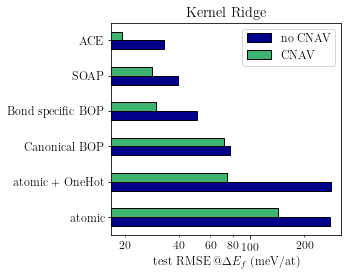

In [30]:
ModelName = 'Kernel Ridge'
NameForFile = ModelName.replace(' ', '')
h = regrouped[ModelName].dropna().shape[0]
fig, ax =  plt.subplots(figsize=(5,4)) #(12, 1.2*(h+1)))
ax = (1000*regrouped[ModelName].dropna().sort_values(by='CNAV', ascending=False)).plot.barh(color = [ 'darkblue','mediumseagreen'], edgecolor='k', ax = ax, width=0.5)
ax.set_xscale('log', subs = [2,4,6,8,10])
xlabels = ax.get_yticklabels()
newlabels = [l.get_text().replace('+','+\n') for l in xlabels]
newlabels = [l.replace('_specific','') for l in newlabels]
newlabels = [l.replace('Pyscal','Steinhardt') for l in newlabels]
#newlabels = [l.replace('atomic','Matminer') for l in newlabels]
newlabels = [l.replace('dataset','polyhedra') for l in newlabels]
newlabels = [l.replace('sOS','OS') for l in newlabels]
newlabels = [l.replace('0.7 Projections OS', 'Bond specific') for l in newlabels]
newlabels = [l.replace('polyhedra', 'atomic + OneHot') for l in newlabels]
xls = ax.set_yticklabels(newlabels)
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
ax.set_title(ModelName)
plt.tight_layout()
plt.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_structural_domain_{NameForFile}_{target_name}.pdf'))

In [31]:
models = pd.DataFrame.from_dict({modelname: regrouped_scores['CNAV'] for modelname, regrouped_scores in regrouped.items()})
models.sort_values(by=['Random Forest'], inplace=True, ascending=False)

In [32]:
models = models[['Random Forest',  'MLP', 'Kernel Ridge']]

In [33]:
models.index = models.index.str.replace('_specific','')

In [34]:
models = models.query('~index.str.contains("^0.8|^0.6|canonicalFe")')

In [35]:
models

,Random Forest,MLP,Kernel Ridge
atomic,0.118990,0.139393,0.142624
dataset,0.084718,0.091747,0.074479
Canonical BOP,0.075793,0.062107,0.071510
SOAP,0.051438,0.035665,0.028275
0.7 Projections OS BOP,0.050412,0.046725,0.029837
ACE,0.039473,0.028193,0.019255


In [45]:
models_nocnav = pd.DataFrame.from_dict({modelname: regrouped_scores['no CNAV'] for modelname, regrouped_scores in regrouped.items()})
models_nocnav.sort_values(by=['Kernel Ridge'], inplace=True, ascending=False)

In [46]:
models_nocnav = models_nocnav[['Random Forest',  'MLP', 'Kernel Ridge']]

In [47]:
models_nocnav.index = models_nocnav.index.str.replace('_specific','')

In [48]:
models_nocnav = models_nocnav.query('~index.str.contains("^0.8|^0.6|canonicalFe")')

In [49]:
models_nocnav

,Random Forest,MLP,Kernel Ridge
dataset,NaN,NaN,0.280363
atomic,NaN,NaN,0.278512
Canonical BOP,0.091326,0.070404,0.077252
0.7 Projections OS BOP,0.061582,0.054744,0.050276
SOAP,0.059415,0.054859,0.039712
ACE,0.043284,0.032485,0.033259


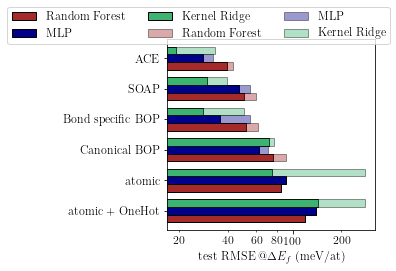

In [50]:
h = models.shape[0]
fig, ax = plt.subplots(figsize= (5,4))#(12, 1.2*(h+1)))
(1000*models).plot.barh(
    color = [ 'brown', 'darkblue',  'mediumseagreen'],
    edgecolor='k',
    ax = ax, 
    width = 0.75
)
(1000*models_nocnav).plot.barh(
    color = [ 'brown', 'darkblue',  'mediumseagreen'],
    edgecolor='k',
    alpha = 0.4,
    ax = ax, 
    width = 0.75
)
ax.set_xscale('log', subs=[2,4,6,8,10])
xlabels = ax.get_yticklabels()
newlabels = [l.get_text().replace('+','+\n') for l in xlabels]
#newlabels = [l.replace('Pyscal','Steinhardt') for l in newlabels]
#newlabels = [l.replace('atomic','Matminer') for l in newlabels]
newlabels = [l.replace('dataset','atomic + OneHot') for l in newlabels]
newlabels = [l.replace('sOS','OS') for l in newlabels]
newlabels = [l.replace('0.7 Projections OS', 'Bond specific') for l in newlabels]
xls = ax.set_yticklabels(newlabels)
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
plt.legend(ncol = 3, bbox_to_anchor = (0.1, 1, 1,0.2))
fig.tight_layout()
#fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_comparemodels_{target_name}.pdf'))
fig.savefig(os.path.join(DS.dataset,'graphs', f'Figure_OptimalRegresorComparison.pdf'))

# Accumulating knowledge

In [37]:
Y = DS.target

In [38]:
thisfeatures  = Features['Projections BOP'].filter(regex='normed_moments.*_0$')

In [39]:
thismodelname = 'Random Forest'

In [40]:
RMSEincremental = {}
for i, column in tqdm(enumerate(thisfeatures.columns), total = thisfeatures.shape[1]):
    X = pd.concat([Features['dataset']['Mag'],thisfeatures.iloc[:,:i+1]], axis=1)
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, shuffle=True)
    models[thismodelname].fit(xtrain, ytrain)
    Ypredict = models[thismodelname].predict(xtrain)
    Ypredicttest = models[thismodelname].predict(xtest)
    RMSEincremental[(thismodelname, column)] = {
        'train' : mean_squared_error(ytrain, Ypredict, squared = False),
        'test' : mean_squared_error(ytest, Ypredicttest, squared=False)
    }
    

  0%|          | 0/15 [00:00<?, ?it/s]

AttributeError: 'Series' object has no attribute 'fit'

In [ ]:
pd.DataFrame.from_dict(RMSEincremental, orient='index')

In [ ]:
thismodel = RandomForestRegressor()

In [ ]:
thismodel.fit(Features['dataset'], Y)

In [ ]:
Ypredict = thismodel.predict(Features['dataset'])

In [ ]:
mean_squared_error(Y, Ypredict, squared=False)

# Helper Functions 

In [ ]:
from Tools.DatasetTools.Tools import CaseNamer, Plotting

In [ ]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [ ]:
DS.dataset

## Load the BOP for the selected case

# Classification and weighting

In [ ]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [ ]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [ ]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [ ]:
from sklearn.feature_selection import  (RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [ ]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [ ]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

In [ ]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [ ]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [ ]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [ ]:
simple_model.fit(X_train,Y_train)

In [ ]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [ ]:
mses

In [ ]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [ ]:
simple_model_noscaler.fit(X_train, Y_train)

In [ ]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [ ]:
mses

In [ ]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

In [ ]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [ ]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

In [ ]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

In [ ]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [ ]:
ERRORS[ERRORS > 0.35]

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [ ]:
Selector = SelectKBest(mutual_info_regression, k=10)
Selector.fit(X_train[real_feature], Y_train)

In [ ]:
simple_model = RandomForestRegressor()

In [ ]:
np.array(real_feature)[Selector.get_support()]

In [ ]:
simple_model.fit(X_train[np.array(real_feature)[Selector.get_support()]], Y_train)

In [ ]:
Y_predict = simple_model.predict(X_train[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [ ]:
mses

### on a pipeline

In [ ]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest()),
        ('regression', RandomForestRegressor())
    ]
)

In [ ]:
RF_SelectKbest.fit(X_train, Y_train)

In [ ]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [ ]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

### with cross validation

In [ ]:
Params= {'feature_selection__k':np.arange(5,15), 'regression__max_depth':[20]} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [ ]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=2,n_jobs=2,)

In [ ]:
Validator.fit(X_train, Y_train)

In [ ]:
Validator.best_estimator_

In [ ]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [ ]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [ ]:
y = Validator.cv_results_['mean_test_score']

In [ ]:
plt.plot(x,-y)

In [ ]:
np.array(real_feature)[Validator.best_estimator_[0].get_support()]

## just in a loop

In [ ]:
RF_SelectKbest

In [ ]:
for k in range(10,20):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances, model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

In [ ]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [ ]:
mses

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [ ]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [ ]:
SeqSelector.fit(X_train, Y_train)

In [ ]:
SeqSelector

In [ ]:
X_train.columns[SeqSelector.get_support()]

In [ ]:
features = X_train.columns[SeqSelector.get_support()]

In [ ]:
allfeatures = features.append( pd.Index(['MagConfig_0']))

In [ ]:
allfeatures

In [ ]:
model = RandomForestRegressor(max_depth=20)

In [ ]:
model.fit(X_train[allfeatures], Y_train)

In [ ]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[allfeatures]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[allfeatures]),squared=False),
    'features_selected': allfeatures, 'importances_selected' : model.feature_importances_
}

In [ ]:
mses

In [ ]:
with open('mses.pkl','wb') as f:
    pickle.dump(mses,f)

In [ ]:
model.feature_importances_

In [ ]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, allfeatures,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [ ]:
Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                 scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)

In [ ]:
Selector.fit(X_train, Y_train)

In [ ]:
import joblib

In [ ]:
joblib.dump(Selector, 'SelectorRFECV')

In [ ]:
Selector.support_

In [ ]:
Selector.grid_scores_

In [ ]:
thisfeatures = X_train.columns[Selector.support_]

In [ ]:
order = np.argsort(Selector.estimator_.feature_importances_)

In [ ]:
thisfeatures[order]

In [ ]:
plt.plot(Selector.estimator_.feature_importances_[order], thisfeatures[order])

# My Old Feature Concatenation 

In [ ]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

In [ ]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [ ]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [ ]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

In [ ]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

In [ ]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [ ]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [ ]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [ ]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [ ]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

In [ ]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

In [ ]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

In [ ]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [ ]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [ ]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [ ]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

In [ ]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')